In [ ]:

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12,4)

In [ ]:
FLUX_PATH = "/content/sci_xrsf-l2-avg1m_g18_y2025_v2-2-0.nc"


def open_nc_robust(path):
    for eng in ["netcdf4","h5netcdf"]:
        try:
            ds = xr.open_dataset(path, engine=eng)
            print(f"✔ Cargado con engine='{eng}':", Path(path).name)
            return ds
        except Exception as e:
            print(f"✘ Engine '{eng}' falló:", e)
    raise RuntimeError("No se pudo abrir el NetCDF. Revisa que el archivo no esté corrupto.")

ds_flux = open_nc_robust(FLUX_PATH)

# A DataFrame y limpieza mínima
df_flux = ds_flux.to_dataframe().reset_index()
assert {"time","xrsb_flux","xrsa_flux"}.issubset(df_flux.columns), df_flux.columns.tolist()

df_flux = (df_flux[["time","xrsb_flux","xrsa_flux"]]
           .dropna()
           .assign(time=lambda d: pd.to_datetime(d["time"], utc=True))
           .sort_values("time")
           .set_index("time"))
print("XRS 1-min:", df_flux.shape)
df_flux.head()


✘ Engine 'netcdf4' falló: unrecognized engine 'netcdf4' must be one of your download engines: ['h5netcdf', 'scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
✔ Cargado con engine='h5netcdf': sci_xrsf-l2-avg1m_g18_y2025_v2-2-0.nc
XRS 1-min: (1591372, 2)


,xrsb_flux,xrsa_flux
time,,
2025-01-01 00:01:00+00:00,0.000006,2.475166e-07
2025-01-01 00:01:00+00:00,0.000006,2.475166e-07
2025-01-01 00:01:00+00:00,0.000006,2.475166e-07
2025-01-01 00:01:00+00:00,0.000006,2.475166e-07
2025-01-01 00:02:00+00:00,0.000006,2.463455e-07


Juntamos los dos datasets para identificar las fulguraciones más intensas (tipo M o X).

In [ ]:
FLSUM_PATH = "/content/sci_xrsf-l2-flsum_g18_s20220810_e20251012_v2-2-0.nc"
ds_flsum = open_nc_robust(FLSUM_PATH)
df_flsum = ds_flsum.to_dataframe().reset_index()
print("Columnas flsum (primeras 40):", df_flsum.columns.tolist()[:40])

# Detectar columna de pico y de clase de forma flexible
time_candidates = [c for c in df_flsum.columns if "peak" in c.lower() and "time" in c.lower()]
if not time_candidates:
    # fallback
    if "status" in df_flsum.columns and "time" in df_flsum.columns:
        time_col = "time"
        df_peaks = df_flsum.loc[df_flsum["status"].astype(str).str.upper()=="EVENT_PEAK"].copy()
    else:
        time_candidates = [c for c in df_flsum.columns if "time" in c.lower()]
        time_col = time_candidates[0]
        df_peaks = df_flsum.copy()
else:
    time_col = time_candidates[0]
    df_peaks = df_flsum.copy()

class_candidates = [c for c in df_flsum.columns if "flare_class" in c.lower() or "goescls" in c.lower() or "class" in c.lower()]
assert class_candidates, "No encuentro columna de clase en Flare Summary"
class_col = class_candidates[0]

# Normalizar
df_peaks = df_peaks[[time_col, class_col]].dropna()
df_peaks[time_col] = pd.to_datetime(df_peaks[time_col], utc=True, errors="coerce")
df_peaks[class_col] = df_peaks[class_col].astype(str).str.strip().str.upper()
df_peaks = df_peaks.dropna(subset=[time_col])

# Extra y filtro
df_peaks["class_letter"] = df_peaks[class_col].str[0]
df_peaks["class_value"]  = pd.to_numeric(df_peaks[class_col].str[1:], errors="coerce")

# Sólo M/X y solo 2025
df_mx_2025 = df_peaks.loc[
    df_peaks["class_letter"].isin(["M","X"]) &
    (df_peaks[time_col].dt.year == 2025)
].sort_values(time_col)
print("Fulguraciones M/X en 2025:", len(df_mx_2025))
df_mx_2025.head(10)


✘ Engine 'netcdf4' falló: unrecognized engine 'netcdf4' must be one of your download engines: ['h5netcdf', 'scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
✔ Cargado con engine='h5netcdf': sci_xrsf-l2-flsum_g18_s20220810_e20251012_v2-2-0.nc
Columnas flsum (primeras 40): ['time', 'xrsb_flux', 'status', 'background_flux', 'flare_class', 'integrated_flux', 'flare_id']
Fulguraciones M/X en 2025: 237


,time,flare_class,class_letter,class_value
26185,2025-01-01 04:45:00+00:00,M1.1,M,1.1
26206,2025-01-01 15:24:00+00:00,M1.0,M,1.0
26210,2025-01-01 18:17:00+00:00,M1.2,M,1.2
26219,2025-01-01 21:41:00+00:00,M1.1,M,1.1
26237,2025-01-02 17:40:00+00:00,M1.1,M,1.1
26252,2025-01-03 11:39:00+00:00,X1.2,X,1.2
26263,2025-01-03 22:12:00+00:00,M2.3,M,2.3
26266,2025-01-03 22:41:00+00:00,X1.1,X,1.1
26269,2025-01-03 23:24:00+00:00,M1.9,M,1.9
26273,2025-01-03 23:56:00+00:00,M5.8,M,5.8


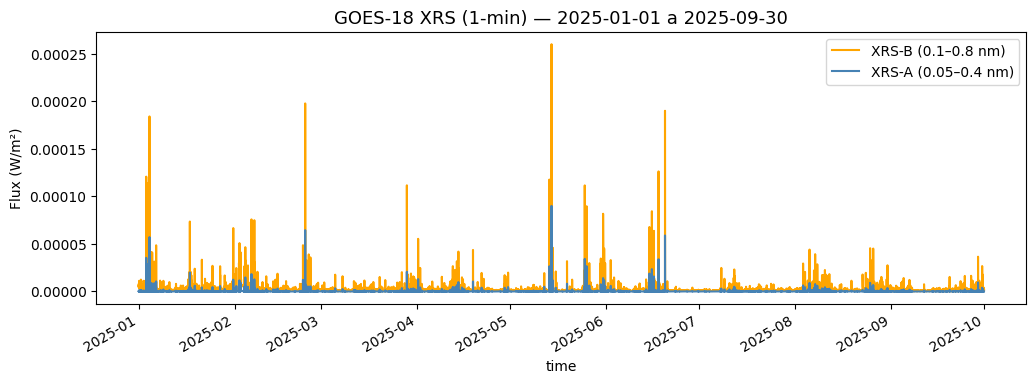

In [ ]:
# Rango temporal
start, end = "2025-01-01", "2025-09-30"

segment = df_flux.loc[start:end]

ax = segment["xrsb_flux"].plot(color="orange", label="XRS-B (0.1–0.8 nm)")
segment["xrsa_flux"].plot(ax=ax, color="steelblue", label="XRS-A (0.05–0.4 nm)")

ax.set_title(f"GOES-18 XRS (1-min) — {start} a {end}", fontsize=13)
ax.set_ylabel("Flux (W/m²)")
ax.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


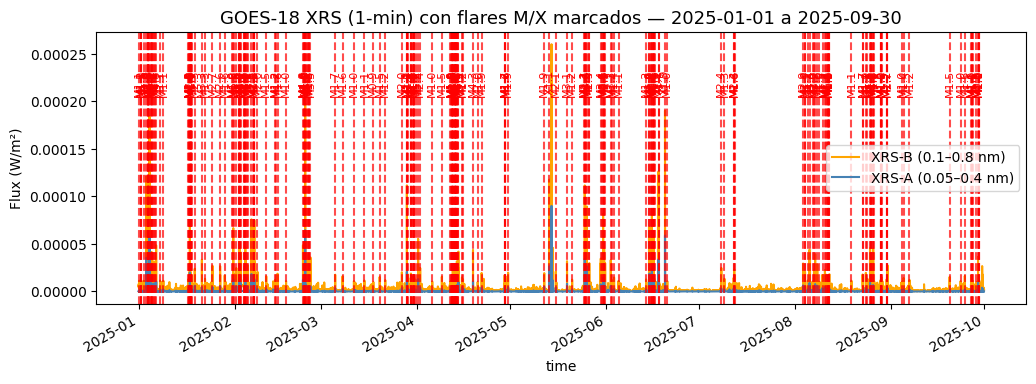

In [ ]:
# Filtramos los flares dentro del rango visible
peaks_in_range = df_mx_2025[
    (df_mx_2025["time"] >= pd.to_datetime(start, utc=True)) &
    (df_mx_2025["time"] <= pd.to_datetime(end, utc=True))
]

ax = segment["xrsb_flux"].plot(color="orange", label="XRS-B (0.1–0.8 nm)")
segment["xrsa_flux"].plot(ax=ax, color="steelblue", label="XRS-A (0.05–0.4 nm)")

# Añadimos líneas y etiquetas de cada flare
for t, cls in zip(peaks_in_range["time"], peaks_in_range["flare_class"]):
    ax.axvline(t, color="red", linestyle="--", alpha=0.7)
    ax.text(t, segment["xrsb_flux"].max()*0.9, cls, rotation=90, va="top", ha="center", fontsize=8, color="red")

ax.set_title(f"GOES-18 XRS (1-min) con flares M/X marcados — {start} a {end}", fontsize=13)
ax.set_ylabel("Flux (W/m²)")
ax.legend()
plt.show()

Se ven las fulguraciones M/X como líneas verticales rojas con sus etiquetas (por ejemplo M3.1, X1.0).
Si el rango es largo (por ejemplo varios meses), puede tardar un poco en renderizar o aparecer muy denso.

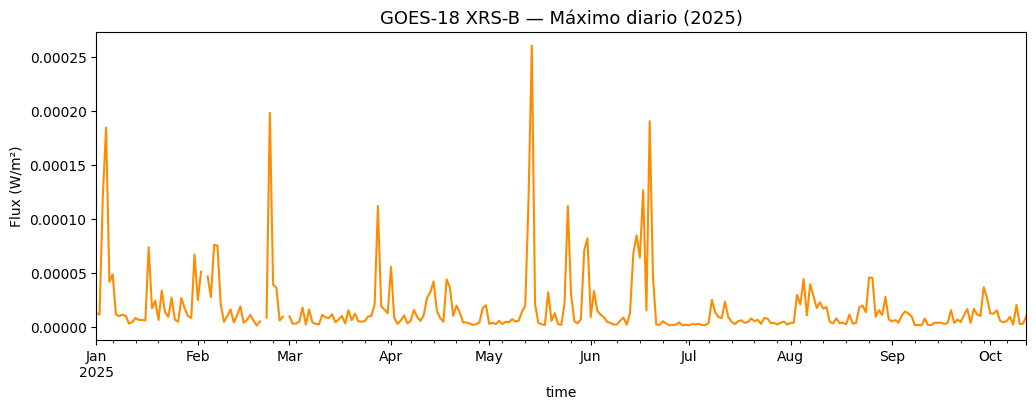

,xrsb_flux
time,
2025-05-14 00:00:00+00:00,0.000260
2025-02-23 00:00:00+00:00,0.000198
2025-06-19 00:00:00+00:00,0.000190
2025-01-04 00:00:00+00:00,0.000184
2025-06-17 00:00:00+00:00,0.000126
2025-01-03 00:00:00+00:00,0.000121
2025-05-13 00:00:00+00:00,0.000118
2025-03-28 00:00:00+00:00,0.000112
2025-05-25 00:00:00+00:00,0.000112


In [ ]:
# Máximo diario sin perder resolución de 1min
daily_max = df_flux["xrsb_flux"].resample("1D").max()
ax = daily_max.plot(color="darkorange")
ax.set_title("GOES-18 XRS-B — Máximo diario (2025)", fontsize=13)
ax.set_ylabel("Flux (W/m²)")
plt.show()

# Mostrar los 10 picos más altos del año
daily_max.sort_values(ascending=False).head(10)


In [ ]:
mx_tbl = df_mx_2025[["time", "flare_class", "class_letter", "class_value"]].reset_index(drop=True)
print("Total de flares M/X en 2025:", len(mx_tbl))
mx_tbl.head(20)

Total de flares M/X en 2025: 237


,time,flare_class,class_letter,class_value
0,2025-01-01 04:45:00+00:00,M1.1,M,1.1
1,2025-01-01 15:24:00+00:00,M1.0,M,1.0
2,2025-01-01 18:17:00+00:00,M1.2,M,1.2
3,2025-01-01 21:41:00+00:00,M1.1,M,1.1
4,2025-01-02 17:40:00+00:00,M1.1,M,1.1
5,2025-01-03 11:39:00+00:00,X1.2,X,1.2
6,2025-01-03 22:12:00+00:00,M2.3,M,2.3
7,2025-01-03 22:41:00+00:00,X1.1,X,1.1
8,2025-01-03 23:24:00+00:00,M1.9,M,1.9
9,2025-01-03 23:56:00+00:00,M5.8,M,5.8


Etiquetamos. Marcamos 1 si habra flare M/x en los proximos 45 minutos

In [ ]:
import pandas as pd
import numpy as np

df = df_flux.copy()  # 1-min
df = df.sort_index()

# Inicializa etiquetas
TARGET = "is_MX_next45"
df["flare_type"] = "none"
df[TARGET] = 0

# 1) “Evento ahora” (para inspección): ±10 min alrededor del pico
win_now = pd.Timedelta("10min")
for t, cls in zip(df_mx_2025["time"], df_mx_2025["flare_class"].astype(str)):
    f = cls.strip().upper()[0]
    mask = (df.index >= t - win_now) & (df.index <= t + win_now)
    if f == "X":
        df.loc[mask, "flare_type"] = "X"
    elif f == "M":
        df.loc[mask & (df["flare_type"] != "X"), "flare_type"] = "M"

df["is_MX_now"] = df["flare_type"].isin(["M","X"]).astype(int)

# 2) Objetivo: próximos 45 minutos (no inclusivo el pico)
for t in df_mx_2025["time"]:
    mask = (df.index >= t - pd.Timedelta("45min")) & (df.index < t)
    df.loc[mask, TARGET] = 1

print("Proporción positivos (next45):", df[TARGET].mean().round(4))
df[[TARGET, "is_MX_now", "flare_type"]].head(10)


Proporción positivos (next45): 0.0257


,is_MX_next45,is_MX_now,flare_type
time,,,
2025-01-01 00:01:00+00:00,0,0,none
2025-01-01 00:01:00+00:00,0,0,none
2025-01-01 00:01:00+00:00,0,0,none
2025-01-01 00:01:00+00:00,0,0,none
2025-01-01 00:02:00+00:00,0,0,none
2025-01-01 00:02:00+00:00,0,0,none
2025-01-01 00:02:00+00:00,0,0,none
2025-01-01 00:02:00+00:00,0,0,none
2025-01-01 00:03:00+00:00,0,0,none


Nos quedamos con los positivos, negativos dificiles (+-6h de eventos) y unpoco del resto. Para mejorar la señal para modelos.

In [ ]:
# Marca “cercano a evento” ±6h
near = pd.Series(False, index=df.index)
for t in df_mx_2025["time"]:
    near.loc[t - pd.Timedelta("6h"): t + pd.Timedelta("6h")] = True

neg_far = df[(df[TARGET]==0) & (~near)]
keep_far = neg_far.sample(min(len(neg_far), 30000), random_state=42)  # 30k “fáciles”

df_small = pd.concat([
    df[df[TARGET]==1],           # todos los positivos
    df[(df[TARGET]==0) & near],  # negativos difíciles
    keep_far                     # muestra de fáciles
]).sort_index()

print("Tamaño:", df_small.shape, "  Ratio positivos:", round(df_small[TARGET].mean(),4))


Tamaño: (446020, 5)   Ratio positivos: 0.0916


Aceleraciones logaritmicas y contrastes. Para distinguir subidas reales y las de fondo (ruido).

In [ ]:
X = df_small.copy()

# Log y aceleraciones
X["log_xrsb"]   = np.log10(np.clip(X["xrsb_flux"], 1e-9, None))
X["log_diff1"]  = X["log_xrsb"].diff().fillna(0)                     # d/dt log
X["log_diff5"]  = X["log_xrsb"].diff().rolling(5, min_periods=1).mean().fillna(0)

# Medias móviles (en minutos, porque resolución es 1 min)
X["xrsb_ma5"]   = X["xrsb_flux"].rolling(5,  min_periods=1).mean()
X["xrsb_ma15"]  = X["xrsb_flux"].rolling(15, min_periods=1).mean()
X["ma30"]       = X["xrsb_flux"].rolling(30, min_periods=1).mean()
X["ma60"]       = X["xrsb_flux"].rolling(60, min_periods=1).mean()
X["xrsb_diff1"] = X["xrsb_flux"].diff().fillna(0)
X["xrsb_rslope15"] = (X["xrsb_flux"] - X["xrsb_ma15"])

# Contrastes
X["ratio_ma5_ma30"] = (X["xrsb_ma5"] / (X["ma30"] + 1e-12)).fillna(1.0)
X["ratio_ma5_ma60"] = (X["xrsb_ma5"] / (X["ma60"] + 1e-12)).fillna(1.0)
X["zscore_30"] = ((X["xrsb_flux"] - X["ma30"]) /
                  (X["xrsb_flux"].rolling(30, min_periods=1).std() + 1e-12)).fillna(0)

# Relación canal A/B
X["xrsa_over_xrsb"] = (X["xrsa_flux"] / (X["xrsb_flux"] + 1e-12)).clip(0, 100)

FEAT_COLS = [
    "xrsb_flux","xrsa_flux","xrsb_ma5","xrsb_ma15","xrsb_diff1","xrsb_rslope15",
    "log_xrsb","log_diff1","log_diff5","ratio_ma5_ma30","ratio_ma5_ma60",
    "zscore_30","xrsa_over_xrsb"
]
y = X[TARGET].astype(int)


Split temporales.

In [ ]:
from sklearn.preprocessing import StandardScaler

train = X.loc["2025-01-01":"2025-08-31"]
val   = X.loc["2025-09-01":"2025-09-30"]
test  = X.loc["2025-10-01":]

scaler = StandardScaler()
Xtr = scaler.fit_transform(train[FEAT_COLS])
Xva = scaler.transform(val[FEAT_COLS])
Xte = scaler.transform(test[FEAT_COLS])

ytr = train[TARGET].astype(int).values
yva = val[TARGET].astype(int).values
yte = test[TARGET].astype(int).values

Xtr.shape, Xva.shape, Xte.shape, ytr.mean().round(4), yva.mean().round(4), yte.mean().round(4)


((393312, 13),
 (36630, 13),
 (16078, 13),
 np.float64(0.0945),
 np.float64(0.0713),
 np.float64(0.0672))

LSTM AHORA

In [ ]:
# LSTM
import tensorflow as tf
from tensorflow import keras
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report, average_precision_score

# Parámetros
WINDOW = 120             # 2h a 1 min
BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 15
PATIENCE = 6

# Datasets de secuencias
train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=Xtr, targets=ytr, sequence_length=WINDOW, sequence_stride=1,
    sampling_rate=1, shuffle=True, batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=Xva, targets=yva, sequence_length=WINDOW, sequence_stride=1,
    sampling_rate=1, shuffle=False, batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=Xte, targets=yte, sequence_length=WINDOW, sequence_stride=1,
    sampling_rate=1, shuffle=False, batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

# Pesos de clase
n_pos = int(np.sum(ytr))
n_neg = int(len(ytr) - n_pos)
total = int(len(ytr))
class_weight = {0: total / (2.0 * max(n_neg,1)), 1: total / (2.0 * max(n_pos,1))}

# Modelo LSTM
tf.keras.backend.clear_session()
inputs = keras.Input(shape=(WINDOW, Xtr.shape[1]))
x = keras.layers.Masking()(inputs)
x = keras.layers.LSTM(64, return_sequences=True)(x)
x = keras.layers.LSTM(32)(x)
x = keras.layers.Dropout(0.4)(x)
x = keras.layers.Dense(32, activation="relu")(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)

lstm = keras.Model(inputs, outputs)
lstm.compile(optimizer=keras.optimizers.Adam(LR),
             loss="binary_crossentropy",
             metrics=[keras.metrics.AUC(name="auc"),
                      keras.metrics.AUC(name="prauc", curve="PR")])

cb = [keras.callbacks.EarlyStopping(monitor="val_prauc", mode="max",
                                    patience=PATIENCE, restore_best_weights=True)]
history = lstm.fit(train_ds, validation_data=val_ds,
                   epochs=EPOCHS, class_weight=class_weight,
                   callbacks=cb, verbose=1)

# Predicciones streaming selección de umbral por precisión objetivo
probs_list, y_true_list = [], []
for xb, yb in test_ds:
    probs_list.append(lstm.predict(xb, verbose=0).ravel())
    y_true_list.append(yb.numpy().ravel())
probs = np.concatenate(probs_list)
y_true = np.concatenate(y_true_list).astype(int)

prec, rec, thr = precision_recall_curve(y_true, probs)
PREC_OBJ = 0.55
idx = np.where(prec[:-1] >= PREC_OBJ)[0]
if len(idx)==0:
    k = np.argmax(2*prec*rec/(prec+rec+1e-9))  # F1
else:
    k = idx[np.argmax(rec[idx])]
best_thr = thr[k]

print(f"LSTM: AP={average_precision_score(y_true, probs):.3f} | umbral={best_thr:.3f} | P={prec[k]:.3f} R={rec[k]:.3f}")
yhat = (probs >= best_thr).astype(int)
print(classification_report(y_true, yhat, digits=4))

Epoch 1/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - auc: 0.9370 - loss: 0.2998 - prauc: 0.7891 - val_auc: 0.9453 - val_loss: 0.1830 - val_prauc: 0.8087
Epoch 2/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 75s 49ms/step - auc: 0.9600 - loss: 0.2313 - prauc: 0.8788 - val_auc: 0.9413 - val_loss: 0.2012 - val_prauc: 0.7903
Epoch 3/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - auc: 0.9609 - loss: 0.2351 - prauc: 0.8709 - val_auc: 0.9322 - val_loss: 0.2098 - val_prauc: 0.7466
Epoch 4/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 75s 49ms/step - auc: 0.9646 - loss: 0.2211 - prauc: 0.8856 - val_auc: 0.9355 - val_loss: 0.1787 - val_prauc: 0.8005
Epoch 5/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - auc: 0.9713 - loss: 0.2021 - prauc: 0.8982 - val_auc: 0.9338 - val_loss: 0.1890 - val_prauc: 0.7918
Epoch 6/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 74s 48ms/step - auc: 0.9713 - loss: 0.2005 - prauc: 0.9007 - val_auc: 0.9075 - val_loss: 0.1864 - val_prauc: 0.7704
Epoch 7/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/s

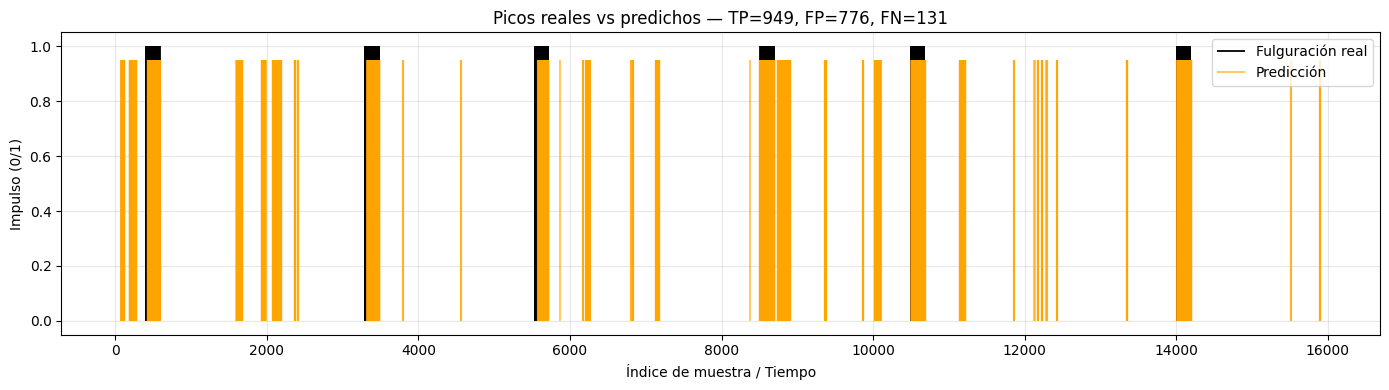

In [ ]:
# === FULGURACIONES — Picos reales vs predichos (vista clara) ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Detectar variables automáticamente ---
# Reales
if 'y_te' in locals():
    y_true_test = np.asarray(y_te).astype(int).ravel()
elif 'y_test' in locals():
    y_true_test = np.asarray(y_test).astype(int).ravel()
elif 'y_true' in locals():
    y_true_test = np.asarray(y_true).astype(int).ravel()
else:
    raise NameError("No se encontró y_te, y_test ni y_true. Ejecuta antes la celda de evaluación del modelo.")

# Probabilidades / predicciones
if 'probs' in locals():
    probs_test = np.asarray(probs).ravel()
    thr = float(best_thr) if 'best_thr' in locals() else 0.5
    y_pred_test = (probs_test >= thr).astype(int)
elif 'yhat' in locals():
    y_pred_test = np.asarray(yhat).astype(int).ravel()
    probs_test = y_pred_test.astype(float)
else:
    raise NameError("No se encontró probs ni yhat. Ejecuta la celda donde se calculan las predicciones.")

# Eje X
try:
    if hasattr(y_te, "index"):
        x = y_te.index
    elif 'y_test' in locals() and hasattr(y_test, "index"):
        x = y_test.index
    else:
        x = np.arange(len(y_true_test))
except Exception:
    x = np.arange(len(y_true_test))

# métricas y posiciones
tn, fp, fn, tp = confusion_matrix(y_true_test, y_pred_test).ravel()
x_real = x[y_true_test == 1]
x_pred = x[y_pred_test == 1]

#Gráfico
plt.figure(figsize=(14,4))
plt.vlines(x_real, 0, 1.0, color="black", label="Fulguración real", linewidth=1.3)
plt.vlines(x_pred, 0, 0.95, color="orange", label="Predicción", alpha=0.6)

plt.ylim(-0.05, 1.05)
plt.xlabel("Índice de muestra / Tiempo")
plt.ylabel("Impulso (0/1)")
plt.title(f"Picos reales vs predichos — TP={tp}, FP={fp}, FN={fn}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


CNN

In [ ]:
# CNN
import tensorflow as tf
from tensorflow import keras
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report, average_precision_score

# Parámetros
WINDOW = 120             # 2h
BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 15
PATIENCE = 6

# Datasets de secuencias
train_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=Xtr, targets=ytr, sequence_length=WINDOW, sequence_stride=1,
    sampling_rate=1, shuffle=True, batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=Xva, targets=yva, sequence_length=WINDOW, sequence_stride=1,
    sampling_rate=1, shuffle=False, batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    data=Xte, targets=yte, sequence_length=WINDOW, sequence_stride=1,
    sampling_rate=1, shuffle=False, batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

# Pesos de clase
n_pos = int(np.sum(ytr))
n_neg = int(len(ytr) - n_pos)
total = int(len(ytr))
class_weight = {0: total / (2.0 * max(n_neg,1)), 1: total / (2.0 * max(n_pos,1))}

# focal loss
def focal_loss(gamma=1.5, alpha=0.65):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0-eps)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1-y_pred)
        w  = tf.where(tf.equal(y_true, 1), alpha, 1-alpha)
        return -tf.reduce_mean(w * tf.pow(1.-pt, gamma) * tf.math.log(pt))
    return loss

# Modelo CNN temporal (Conv1D)
tf.keras.backend.clear_session()
inputs = keras.Input(shape=(WINDOW, Xtr.shape[1]))
x = inputs
x = keras.layers.Conv1D(64, 5, padding="same", activation="relu")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPooling1D(2)(x)
x = keras.layers.Conv1D(128, 3, padding="same", activation="relu")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPooling1D(2)(x)
x = keras.layers.Conv1D(128, 3, padding="same", activation="relu")(x)
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dropout(0.4)(x)
x = keras.layers.Dense(64, activation="relu")(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)

cnn = keras.Model(inputs, outputs)
cnn.compile(optimizer=keras.optimizers.Adam(LR),
            loss=focal_loss(gamma=1.5, alpha=0.65),
            metrics=[keras.metrics.AUC(name="auc"),
                     keras.metrics.AUC(name="prauc", curve="PR")])

cb = [keras.callbacks.EarlyStopping(monitor="val_prauc", mode="max",
                                    patience=PATIENCE, restore_best_weights=True)]

history = cnn.fit(train_ds, validation_data=val_ds,
                  epochs=EPOCHS, class_weight=class_weight,
                  callbacks=cb, verbose=1)

# Predicción por lotes y selección de umbral
probs_list, y_true_list = [], []
for xb, yb in test_ds:
    probs_list.append(cnn.predict(xb, verbose=0).ravel())
    y_true_list.append(yb.numpy().ravel())
probs = np.concatenate(probs_list)
y_true = np.concatenate(y_true_list).astype(int)

prec, rec, thr = precision_recall_curve(y_true, probs)
PREC_OBJ = 0.55
idx = np.where(prec[:-1] >= PREC_OBJ)[0]
if len(idx)==0:
    k = np.argmax(2*prec*rec/(prec+rec+1e-9))  # F1
else:
    k = idx[np.argmax(rec[idx])]
best_thr = thr[k]

print(f"CNN: AP={average_precision_score(y_true, probs):.3f} | umbral={best_thr:.3f} | P={prec[k]:.3f} R={rec[k]:.3f}")
yhat = (probs >= best_thr).astype(int)
print(classification_report(y_true, yhat, digits=4))

Epoch 1/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 77s 44ms/step - auc: 0.9359 - loss: 0.0262 - prauc: 0.8237 - val_auc: 0.9314 - val_loss: 0.0215 - val_prauc: 0.8012
Epoch 2/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 60s 39ms/step - auc: 0.9606 - loss: 0.0198 - prauc: 0.8881 - val_auc: 0.9400 - val_loss: 0.0211 - val_prauc: 0.8098
Epoch 3/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - auc: 0.9699 - loss: 0.0178 - prauc: 0.9046 - val_auc: 0.9448 - val_loss: 0.0197 - val_prauc: 0.8248
Epoch 4/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 61s 40ms/step - auc: 0.9784 - loss: 0.0155 - prauc: 0.9222 - val_auc: 0.9497 - val_loss: 0.0213 - val_prauc: 0.8126
Epoch 5/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - auc: 0.9863 - loss: 0.0130 - prauc: 0.9415 - val_auc: 0.9492 - val_loss: 0.0211 - val_prauc: 0.8298
Epoch 6/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 60s 39ms/step - auc: 0.9911 - loss: 0.0110 - prauc: 0.9560 - val_auc: 0.9497 - val_loss: 0.0288 - val_prauc: 0.8318
Epoch 7/15
1536/1536 ━━━━━━━━━━━━━━━━━━━━ 58s 38ms/s

,ROC-AUC,PR-AUC (AP),Prevalencia
Test,0.9668,0.8603,0.0677


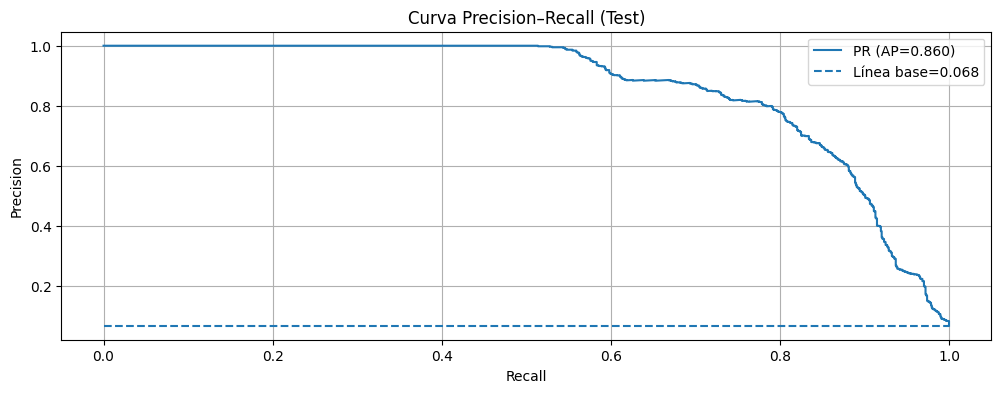

In [ ]:
#Métricas compactas + 1 gráfica PR para el TFM
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

# Entradas esperadas: y_true (0/1) y probs (probabilidad de la clase positiva)
y_true_arr = np.asarray(y_true).astype(int).ravel()
probs_arr  = np.asarray(probs)
if probs_arr.ndim > 1:
    probs_arr = probs_arr[:, -1].ravel()
else:
    probs_arr = probs_arr.ravel()

# Métricas principales
roc_auc = roc_auc_score(y_true_arr, probs_arr)
pr_auc  = average_precision_score(y_true_arr, probs_arr)
prev    = y_true_arr.mean()

# Tabla
res = pd.DataFrame(
    {
        "ROC-AUC": [roc_auc],
        "PR-AUC (AP)": [pr_auc],
        "Prevalencia": [prev],
    },
    index=["Test"]
)
display(res.round(4))

# Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_true_arr, probs_arr)

plt.figure()
plt.plot(rec, prec, label=f"PR (AP={pr_auc:.3f})")
plt.hlines(prev, xmin=0, xmax=1, linestyles="--", label=f"Línea base={prev:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision–Recall (Test)")
plt.legend()
plt.grid(True)
plt.show()
# === Fin ===


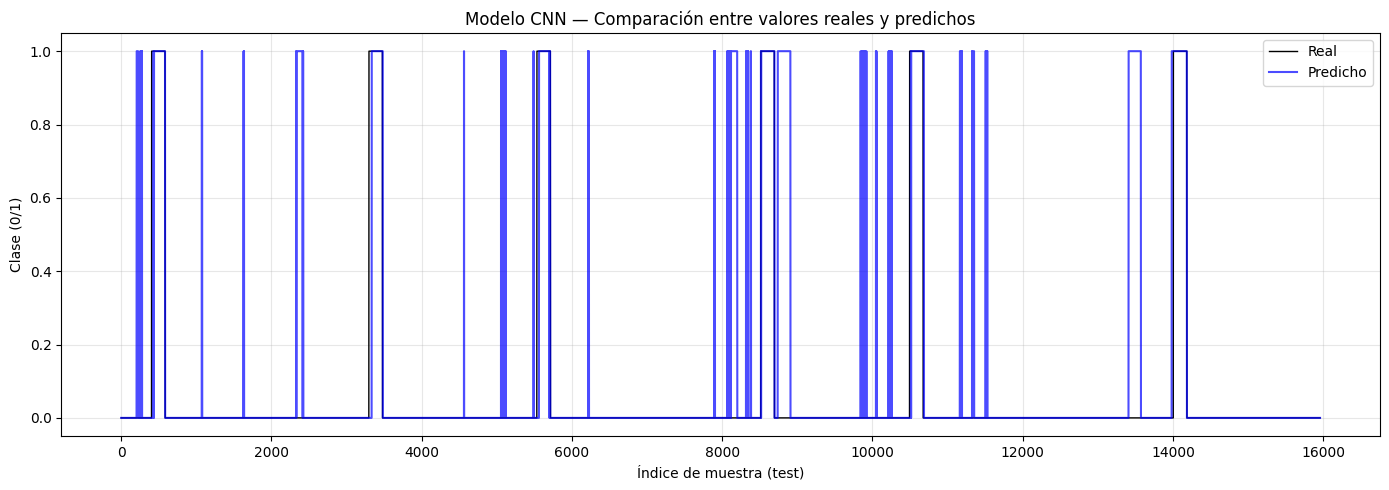

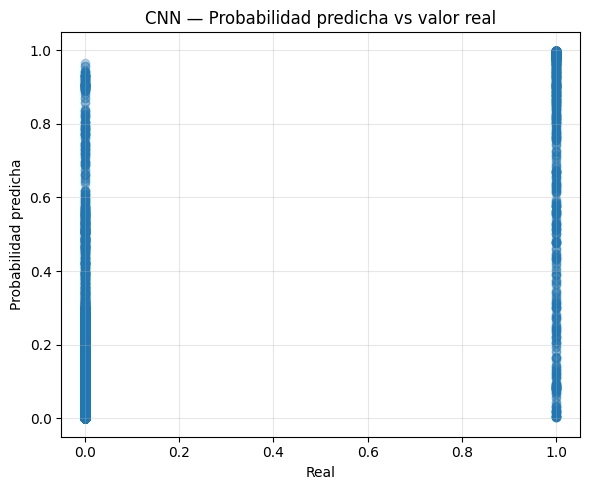

In [ ]:
#VISUALIZACIÓN FINAL: CNN
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


y_true_cnn = y_true.copy()
yhat_cnn = yhat.copy()
probs_cnn = probs.copy()

# DataFrame para visualización
df_cnn = pd.DataFrame({
    "Real": y_true_cnn,
    "Predicho": yhat_cnn,
    "Probabilidad": probs_cnn
})

# Gráfico temporal (índice = secuencia test)
plt.figure(figsize=(14,5))
plt.plot(df_cnn.index, df_cnn["Real"], label="Real", color="black", linewidth=1)
plt.plot(df_cnn.index, df_cnn["Predicho"], label="Predicho", color="blue", alpha=0.7)
plt.title("Modelo CNN — Comparación entre valores reales y predichos")
plt.xlabel("Índice de muestra (test)"); plt.ylabel("Clase (0/1)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()

# Dispersión probabilidad vs realidad
plt.figure(figsize=(6,5))
plt.scatter(df_cnn["Real"], df_cnn["Probabilidad"], alpha=0.3)
plt.title("CNN — Probabilidad predicha vs valor real")
plt.xlabel("Real"); plt.ylabel("Probabilidad predicha")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()


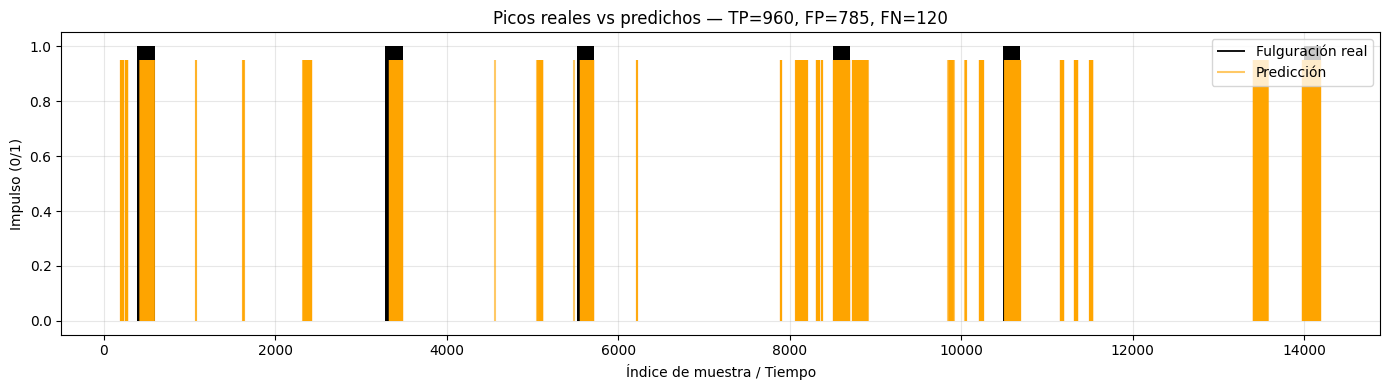

In [ ]:
# FULGURACIONES — Picos reales vs predichos
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Detectar variables automáticamente ---
# Reales
if 'y_te' in locals():
    y_true_test = np.asarray(y_te).astype(int).ravel()
elif 'y_test' in locals():
    y_true_test = np.asarray(y_test).astype(int).ravel()
elif 'y_true' in locals():
    y_true_test = np.asarray(y_true).astype(int).ravel()
else:
    raise NameError("No se encontró y_te, y_test ni y_true. Ejecuta antes la celda de evaluación del modelo.")

# Probabilidades / predicciones
if 'probs' in locals():
    probs_test = np.asarray(probs).ravel()
    thr = float(best_thr) if 'best_thr' in locals() else 0.5
    y_pred_test = (probs_test >= thr).astype(int)
elif 'yhat' in locals():
    y_pred_test = np.asarray(yhat).astype(int).ravel()
    probs_test = y_pred_test.astype(float)
else:
    raise NameError("No se encontró probs ni yhat. Ejecuta la celda donde se calculan las predicciones.")

# Eje X
try:
    if hasattr(y_te, "index"):
        x = y_te.index
    elif 'y_test' in locals() and hasattr(y_test, "index"):
        x = y_test.index
    else:
        x = np.arange(len(y_true_test))
except Exception:
    x = np.arange(len(y_true_test))

# étricas y posiciones
tn, fp, fn, tp = confusion_matrix(y_true_test, y_pred_test).ravel()
x_real = x[y_true_test == 1]
x_pred = x[y_pred_test == 1]

# --- Gráfico ---
plt.figure(figsize=(14,4))
plt.vlines(x_real, 0, 1.0, color="black", label="Fulguración real", linewidth=1.3)
plt.vlines(x_pred, 0, 0.95, color="orange", label="Predicción", alpha=0.6)

plt.ylim(-0.05, 1.05)
plt.xlabel("Índice de muestra / Tiempo")
plt.ylabel("Impulso (0/1)")
plt.title(f"Picos reales vs predichos — TP={tp}, FP={fp}, FN={fn}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()